In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import SelectKBest, chi2
import json
import time


In [2]:
df = pkl.load(open('project8.pkl', 'rb'))
df.shape

(2027, 19)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               2027 non-null   int64  
 1   post_id                  2027 non-null   object 
 2   self_text                2027 non-null   object 
 3   user_is_verified         2027 non-null   object 
 4   controversiality         2027 non-null   float64
 5   ups                      2027 non-null   float64
 6   downs                    2027 non-null   int64  
 7   subreddit                2027 non-null   object 
 8   score                    2027 non-null   float64
 9   user_awardee_karma       2022 non-null   float64
 10  user_awarder_karma       2022 non-null   float64
 11  user_total_karma         2022 non-null   float64
 12  user_comment_karma       2022 non-null   float64
 13  user_link_karma          2022 non-null   float64
 14  post_score              

### Preprocessing

In [4]:
df["preprocessed_text"] = df["self_text"].apply(lambda x: x.lower())

In [5]:
stop_words = set(stopwords.words('english'))
df["tokenized_text"] = df["preprocessed_text"].apply(lambda x: word_tokenize(x))
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word not in stop_words])
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word.isalnum()])
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if len(word) > 1]) # remove single character words, this can help with removing punctuation. 


In [6]:
#group by subreddit
grouped = df.groupby('subreddit')
df_cli_sci = grouped.get_group('climate_science')
df_cli_skp = grouped.get_group('climateskeptics')

print(df_cli_sci.shape)
print(df_cli_skp.shape)

(442, 21)
(1585, 21)


In [7]:
cli_sci_words = [word for words in df_cli_sci["tokenized_text"].values for word in words]
cli_skp_words = [word for words in df_cli_skp["tokenized_text"].values for word in words]

In [8]:
print(len(cli_sci_words))
print(len(cli_skp_words))

123994
487206


In [9]:
common_words = set()
with open ("common_words.txt", "r") as f:
    for line in f:
        common_words.add(line.strip())
        
print(len(common_words))

cli_sci_words = [word for word in cli_sci_words if word not in common_words]
cli_skp_words = [word for word in cli_skp_words if word not in common_words]

print(len(cli_sci_words))
print(len(cli_skp_words))


63
99671
393779


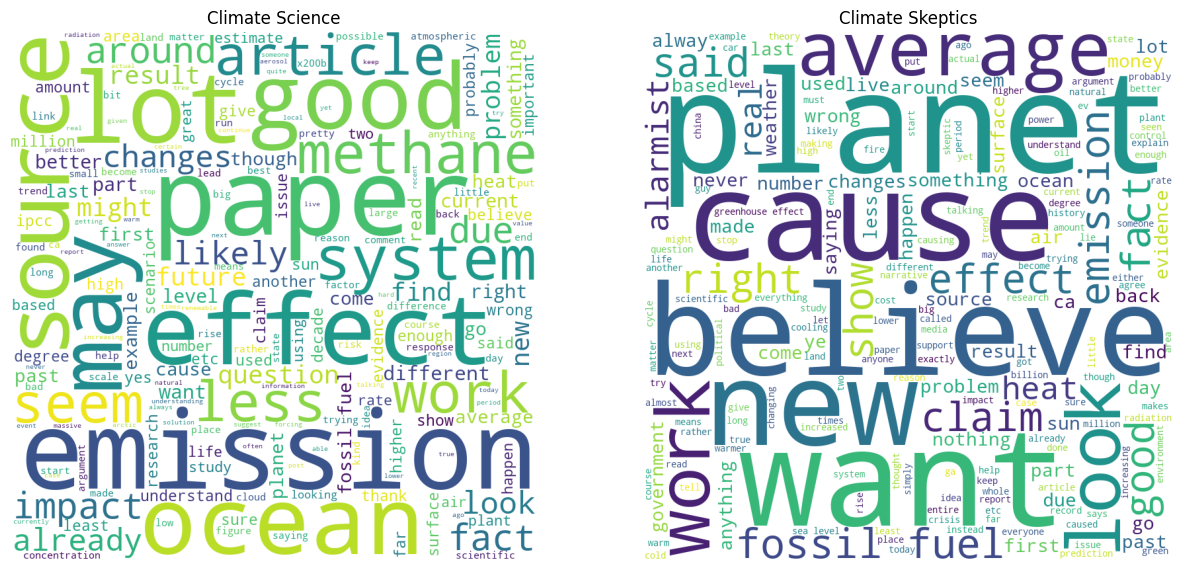

In [10]:
#word cloud for climate science and climate skeptics in subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 15))

wordcloud_cli_sci = WordCloud(width=800, height=800, background_color='white').generate(' '.join(cli_sci_words))
ax[0].imshow(wordcloud_cli_sci)
ax[0].axis('off')
ax[0].set_title('Climate Science')

wordcloud_cli_skp = WordCloud(width=800, height=800, background_color='white').generate(' '.join(cli_skp_words))
ax[1].imshow(wordcloud_cli_skp)
ax[1].axis('off')
ax[1].set_title('Climate Skeptics')

plt.show()

In [11]:
from collections import Counter

total_cli_sci_words = len(cli_sci_words)
total_cli_skp_words = len(cli_skp_words)

cli_sci_word_freq = Counter({word: count / total_cli_sci_words for word, count in Counter(cli_sci_words).items()})
cli_skp_word_freq = Counter({word: count / total_cli_skp_words for word, count in Counter(cli_skp_words).items()})

print(cli_sci_word_freq.most_common(20))
print(cli_skp_word_freq.most_common(20))


[('emissions', 0.004013203439315348), ('methane', 0.0032807938116402964), ('good', 0.0028995394849053386), ('paper', 0.002367790029196055), ('lot', 0.002357757020597767), ('ocean', 0.00227749295181146), ('heat', 0.0022674599432131715), ('may', 0.0022574269346148828), ('effect', 0.0021871958744268645), ('less', 0.0021771628658285762), ('likely', 0.002116964814238846), ('ipcc', 0.0020968987970422692), ('since', 0.002066799771247404), ('might', 0.0020166347282559623), ('greenhouse', 0.001996568711059385), ('due', 0.0019765026938628086), ('already', 0.0019464036680679436), ('around', 0.0019464036680679436), ('different', 0.0019464036680679436), ('changes', 0.0019263376508713668)]
[('heat', 0.0031185004786949025), ('planet', 0.002897564369862283), ('effect', 0.0028163005137399402), ('gas', 0.002595364404907321), ('greenhouse', 0.0024074417376244036), ('since', 0.002211900583830016), ('oil', 0.0022042820973185466), ('weather', 0.002196663610807077), ('believe', 0.002171268655768845), ('new',

In [12]:
#after we have made a list of common words, we can remove them from the tokenized text
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word not in common_words])

In [13]:
top_5000_words = set()
with open("top_5000_words.txt", "r") as f:
    for line in f:
        top_5000_words.add(line.strip())
        
df["preprocessed_text"] = df["tokenized_text"].apply(lambda x: [word for word in x if word in top_5000_words])

df["preprocessed_text"].head()

0    [yes, modeling, anything, less, resolution, ea...
1    [official, paper, describes, effect, supposed,...
2    [read, article, month, ago, sure, claims, look...
3         [paul, provides, textbook, taught, students]
4    [good, interview, hits, lot, climategate, some...
Name: preprocessed_text, dtype: object

### Task 1

In [14]:
#download the google news word2vec model
import gensim.downloader as api
word2vec_model = api.load('word2vec-google-news-300')

In [15]:
most_prominent_words = ['emission', 'source', 'planet', 'believe']
cosine_similarities = cosine_similarity(word2vec_model[most_prominent_words])

cos_sim_df = pd.DataFrame(cosine_similarities, columns=most_prominent_words, index=most_prominent_words)
cos_sim_df

,emission,source,planet,believe
emission,1.000000,0.050124,0.215118,0.022043
source,0.050124,1.000000,0.107579,0.044794
planet,0.215118,0.107579,1.000000,0.084979
believe,0.022043,0.044794,0.084979,1.000000


### Task 2

In [16]:
#averaging the word vectors into a single vector for each post 
df["avg_sentence_vector"] = df["preprocessed_text"].apply(lambda x: np.mean([word2vec_model[word] for word in x if word in word2vec_model.key_to_index], axis=0))

#check the dimension of the average sentence vector of each post
df["avg_sentence_vector"].apply(lambda x: x.shape).value_counts()
df = df.dropna(subset=["avg_sentence_vector"])
    

c:\Users\randy\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

X = np.array(df["avg_sentence_vector"].values.tolist())
y = df["subreddit"].apply(lambda x: 1 if x == "climate_science" else 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
def train_and_test(model, X_train, X_test, y_train, y_test):
    time_start = time.time()
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    time_elapsed = (time.time() - time_start) / 60
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'time_elapsed(m)': time_elapsed}

In [19]:
classifiers = [
    ("Logistic Regression", LogisticRegression()), 
    ("Random Forest", RandomForestClassifier()), 
    ("Naive Bayes", GaussianNB()), 
    ("SVM", SVC())
]
results = {}

for classifier in classifiers:
    name, model = classifier
    results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
print(json.dumps(results, indent=4))

{
    "Logistic Regression": {
        "accuracy": 0.8589108910891089,
        "precision": 0.85,
        "recall": 0.4,
        "f1": 0.544,
        "time_elapsed(m)": 0.00032552878061930336
    },
    "Random Forest": {
        "accuracy": 0.8613861386138614,
        "precision": 0.9142857142857143,
        "recall": 0.3764705882352941,
        "f1": 0.5333333333333333,
        "time_elapsed(m)": 0.022036306063334146
    },
    "Naive Bayes": {
        "accuracy": 0.7673267326732673,
        "precision": 0.46017699115044247,
        "recall": 0.611764705882353,
        "f1": 0.5252525252525253,
        "time_elapsed(m)": 0.00010856389999389649
    },
    "SVM": {
        "accuracy": 0.8985148514851485,
        "precision": 0.8928571428571429,
        "recall": 0.5882352941176471,
        "f1": 0.7092198581560284,
        "time_elapsed(m)": 0.0017543594042460124
    }
}


In [20]:
#using TF-IDF weighted average vector
tfidf = TfidfVectorizer()
documents = df["preprocessed_text"].apply(lambda x: ' '.join(x))
tf_idf_matrix = tfidf.fit_transform(documents)
print(tf_idf_matrix.shape)

def compute_tfidf_avg_vector(doc_index, words):
    vectors = []
    for word in words:
        if word in word2vec_model.key_to_index and word in tfidf.vocabulary_:
            tfidf_weight = tf_idf_matrix[doc_index, tfidf.vocabulary_[word]]
            word_vector = word2vec_model[word]
            vectors.append(tfidf_weight * word_vector)
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return None

df["tfidf_avg_sentence_vector"] = [compute_tfidf_avg_vector(i, words) for i, words in enumerate(df["preprocessed_text"])]

#remove rows with NaN values
df = df.dropna(subset=["tfidf_avg_sentence_vector"])

print(df.shape)

(2020, 5000)
(2020, 23)


C:\Users\randy\AppData\Local\Temp\ipykernel_24292\2437328819.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tfidf_avg_sentence_vector"] = [compute_tfidf_avg_vector(i, words) for i, words in enumerate(df["preprocessed_text"])]


In [21]:
X = np.array(df["tfidf_avg_sentence_vector"].values.tolist())
y = df["subreddit"].apply(lambda x: 1 if x == "climate_science" else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
tfidf_results = {}

for classifier in classifiers:
    name, model = classifier
    tfidf_results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
print("Top 5000 vocab with TF-IDF weighted word2vec average vector aggregation")
print(json.dumps(tfidf_results, indent=4))

Top 5000 vocab with TF-IDF weighted word2vec average vector aggregation
{
    "Logistic Regression": {
        "accuracy": 0.7896039603960396,
        "precision": 0.5,
        "recall": 0.011764705882352941,
        "f1": 0.022988505747126436,
        "time_elapsed(m)": 0.00022513469060262044
    },
    "Random Forest": {
        "accuracy": 0.8094059405940595,
        "precision": 0.8333333333333334,
        "recall": 0.11764705882352941,
        "f1": 0.20618556701030927,
        "time_elapsed(m)": 0.02174129883448283
    },
    "Naive Bayes": {
        "accuracy": 0.31435643564356436,
        "precision": 0.22413793103448276,
        "recall": 0.9176470588235294,
        "f1": 0.36027713625866054,
        "time_elapsed(m)": 0.00010841290156046549
    },
    "SVM": {
        "accuracy": 0.8143564356435643,
        "precision": 0.9166666666666666,
        "recall": 0.12941176470588237,
        "f1": 0.2268041237113402,
        "time_elapsed(m)": 0.001910261313120524
    }
}


### Task 3

In [23]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [24]:
#augment with metadata
df["post_created_time"] = pd.to_datetime(df["post_created_time"])
df['summer'] = df['post_created_time'].dt.month.isin([6, 7, 8]).astype(int)
df['winter'] = df['post_created_time'].dt.month.isin([12, 1, 2]).astype(int)
df['spring'] = df['post_created_time'].dt.month.isin([3, 4, 5]).astype(int)
df['fall'] = df['post_created_time'].dt.month.isin([9, 10, 11]).astype(int)

print(df[["post_created_time", 'summer', 'winter', 'spring', 'fall']].head())


    post_created_time  summer  winter  spring  fall
0 2018-09-18 03:59:40       0       0       0     1
1 2024-02-10 21:56:09       0       1       0     0
2 2023-10-02 14:58:12       0       0       0     1
3 2023-12-14 20:42:33       0       1       0     0
4 2023-10-04 18:12:08       0       0       0     1


In [25]:
#Add metadata features
metadata_features = [   "score", 
                        "user_awardee_karma", 
                        "user_awarder_karma", 
                        "user_total_karma", 
                        "user_comment_karma", 
                        "user_link_karma",
                        "summer",
                        "fall",
                        "winter",
                        "spring",   
                     ]
metadata_matrix = df[metadata_features].values

scaler = MinMaxScaler()
# standardize the metadata features
metadata_matrix = scaler.fit_transform(metadata_matrix)

print(metadata_matrix.shape)
#check if the metadata matrix contains any NaN values
print(np.isnan(metadata_matrix).any())

(2020, 10)
True


In [26]:
X = df["avg_sentence_vector"].values.tolist()
X = np.concatenate([X, metadata_matrix], axis=1)
y = df["subreddit"].apply(lambda x: 1 if x == "climate_science" else 0)

#delete rows with NaN values in X and y
nan_indices = np.isnan(X).any(axis=1)
X = X[~nan_indices]
y = y[~nan_indices]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

metadata_results = {}

for classifier in classifiers:
    name, model = classifier
    metadata_results[name] = train_and_test(model, X_train, X_test, y_train, y_test)
    
print("Top 5000 vocab with avg word2vec average vector aggregation and metadata features")
print(json.dumps(metadata_results, indent=4))


Top 5000 vocab with avg word2vec average vector aggregation and metadata features
{
    "Logistic Regression": {
        "accuracy": 0.8734491315136477,
        "precision": 0.9767441860465116,
        "recall": 0.45652173913043476,
        "f1": 0.6222222222222222,
        "time_elapsed(m)": 0.0003592809041341146
    },
    "Random Forest": {
        "accuracy": 0.8684863523573201,
        "precision": 0.9148936170212766,
        "recall": 0.4673913043478261,
        "f1": 0.6187050359712231,
        "time_elapsed(m)": 0.021642903486887615
    },
    "Naive Bayes": {
        "accuracy": 0.8287841191066998,
        "precision": 0.6419753086419753,
        "recall": 0.5652173913043478,
        "f1": 0.6011560693641619,
        "time_elapsed(m)": 0.00015401442845662435
    },
    "SVM": {
        "accuracy": 0.8560794044665012,
        "precision": 1.0,
        "recall": 0.3695652173913043,
        "f1": 0.5396825396825397,
        "time_elapsed(m)": 0.0014635006586710612
    }
}


### Task 4 Deep learning model

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

#build the embedding matrix using the top 5000 words
embedding_matrix =[[0] * 300] #this matrix will contain the word embeddings for the top 5000 words #the first row will be the embedding for the padding token which is 0
word_indices = {} #this dictionary will map each word to its index in the embedding matrix, this is needed when we train the neural network, the input to the neural network will be the index of the word in the embedding matrix
idx = 1
for i, word in enumerate(top_5000_words):
    if word in word2vec_model.key_to_index:
        embedding_matrix.append(word2vec_model[word])
        word_indices[word] = idx
        idx += 1
    
    else:
        continue
embedding_matrix = np.array(embedding_matrix)
print(embedding_matrix.shape)



(4793, 300)


In [28]:
#LSTM 
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, embedding_matrix, device):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix), freeze=True) #this is the initialization of the embedding layer with the pre-trained word2vec embeddings 
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2) 
        self.fc = nn.Linear(hidden_size, 64)
        self.fc2 = nn.Linear(64, 1)
        self.device = device
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        c0  = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        
        out = self.embedding(x)
        out, _ = self.lstm(out, (h0, c0))
        out = self.fc(out[:, -1, :])
        out = self.fc2(out)
        return torch.sigmoid(out)

In [29]:
#prepare the data  
batch_size = 32

X = df["tokenized_text"].apply(lambda x: [word_indices[word] for word in x if word in top_5000_words and word in word2vec_model.key_to_index]) #convert the words to their corresponding indices in the embedding layer
X = nn.utils.rnn.pad_sequence([torch.tensor(x) for x in X], batch_first=True) #pad the sequences to have the same, length max length is 6901
y = df["subreddit"].apply(lambda x: 1 if x == "climate_science" else 0).values  

#Split into 80% training and 10% validation and 10% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

#convert the data into data loaders
train_dataset = TensorDataset(X_train, torch.tensor(y_train).float())
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val, torch.tensor(y_val).float())
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, torch.tensor(y_test).float())
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)


In [32]:
def train(train_data, validation_data, criterion, optimizer, device, model, num_epochs):
    train_losses = []
    val_losses = []
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        train_corr = 0
        total_train = 0
        for x, y in train_data:
            y = y.unsqueeze(1)
            x, y = x.to(device), y.to(device).float()
            total_train += y.size(0)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            total_loss += loss.item()
            train_corr += ((output > 0.5) == y).sum().item()
            loss.backward()
            optimizer.step() 
        train_losses.append(total_loss / len(train_data))
        
        model.eval()
        with torch.no_grad():
            val_loss = 0
            for x, y in validation_data:
                y = y.unsqueeze(1)
                x, y = x.to(device), y.to(device).float()
                output = model(x)
                val_loss += criterion(output, y).item()
            
            val_losses.append(val_loss /len(validation_data))
            print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_losses[-1]}, Train Accuracy: {train_corr * 100/total_train}%, Validation Loss: {val_loss / len(validation_data)}")
            
    return train_losses, val_losses


def test(test_data, model, device):
    model.eval()
    y_pred = []
    y_true = []
    
    with torch.no_grad():
        for x, y in test_data:
            x, y = x.to(device), y.to(device).float()
            output = model(x).squeeze(1)
            y_pred.extend((output > 0.5).int().tolist())
            y_true.extend(y.int().tolist())
            
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}
        

In [33]:
#hyperparameters
input_size = 300
hidden_size = 128
num_layers = 2
num_classes = 2
learning_rate = 0.05
num_epochs = 5
batch_size = 32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
criterion = nn.BCELoss()

#initialize the model
model = LSTM(input_size, hidden_size, num_layers, num_classes, embedding_matrix, device).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses, val_losses = train(train_loader, val_loader, criterion, optimizer, device, model, num_epochs=10)
result = test(test_loader, model, device)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.show()
print(result)



cuda


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
